# 💰 Revenue Scenario Analysis

This notebook translates forecasted monthly orders into projected revenue scenarios.

## Objectives
- Load forecasted orders
- Load monthly KPI data
- Calculate recent AOV
- Estimate revenue using Orders × AOV
- Build downside / base / upside scenarios
- Visualize business outlook

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

## 1. Load Forecasted Orders

Load forecasted monthly orders generated from the forecasting notebook.

In [17]:
forecast_df = pd.read_csv("orders_forecast.csv")
forecast_df["month"] = pd.to_datetime(forecast_df["month"])
forecast_df = forecast_df.sort_values("month").reset_index(drop=True)

forecast_df.head()

,month,pred_orders,model
0,2011-07-01,1365.666667,Moving Average
1,2011-08-01,1365.666667,Moving Average
2,2011-09-01,1365.666667,Moving Average
3,2011-10-01,1365.666667,Moving Average
4,2011-11-01,1365.666667,Moving Average


## 2. Load Monthly KPI Data

Load historical revenue and order data to calculate Average Order Value (AOV).

In [18]:
kpi_df = pd.read_csv("monthly_kpi.csv")
kpi_df["month"] = pd.to_datetime(kpi_df["month"])
kpi_df = kpi_df.sort_values("month").reset_index(drop=True)

kpi_df.head()

,month,revenue,orders,aov
0,2010-12-01,572713.890,1400,409.081350
1,2011-01-01,569445.040,987,576.945329
2,2011-02-01,447137.350,998,448.033417
3,2011-03-01,595500.760,1321,450.795428
4,2011-04-01,469200.361,1149,408.355406


## 3. Calculate Average Order Value (AOV)

AOV is calculated from historical revenue and order data.

**AOV = Revenue / Orders**

In [19]:
kpi_df["aov"] = kpi_df["revenue"] / kpi_df["orders"]
recent_aov = kpi_df["aov"].tail(3).mean()

print(f"Recent 3-month AOV: ${recent_aov:.2f}")
kpi_df[["month", "revenue", "orders", "aov"]].tail()

Recent 3-month AOV: $547.32


,month,revenue,orders,aov
8,2011-08-01,645343.900,1281,503.781343
9,2011-09-01,952838.382,1756,542.618669
10,2011-10-01,1039318.790,1929,538.786309
11,2011-11-01,1161817.380,2658,437.102099
12,2011-12-01,518192.790,778,666.057571


## 4. Base Revenue Forecast

Estimate projected revenue using forecasted orders and recent AOV.

**Revenue = Orders × AOV**

In [20]:
forecast_df["revenue_base"] = forecast_df["pred_orders"] * recent_aov

forecast_df[["month", "pred_orders", "revenue_base"]]

,month,pred_orders,revenue_base
0,2011-07-01,1365.666667,747450.297323
1,2011-08-01,1365.666667,747450.297323
2,2011-09-01,1365.666667,747450.297323
3,2011-10-01,1365.666667,747450.297323
4,2011-11-01,1365.666667,747450.297323
5,2011-12-01,1365.666667,747450.297323


## 5. Revenue Scenarios

Create downside and upside scenarios around the base forecast.

In [21]:
forecast_df["revenue_downside"] = forecast_df["revenue_base"] * 0.90
forecast_df["revenue_upside"] = forecast_df["revenue_base"] * 1.10

forecast_df[["month", "revenue_downside", "revenue_base", "revenue_upside"]]

,month,revenue_downside,revenue_base,revenue_upside
0,2011-07-01,672705.26759,747450.297323,822195.327055
1,2011-08-01,672705.26759,747450.297323,822195.327055
2,2011-09-01,672705.26759,747450.297323,822195.327055
3,2011-10-01,672705.26759,747450.297323,822195.327055
4,2011-11-01,672705.26759,747450.297323,822195.327055
5,2011-12-01,672705.26759,747450.297323,822195.327055


## 6. Scenario Table

Compare monthly revenue across downside, base, and upside scenarios.

In [22]:
scenario_table = forecast_df[[
    "month", "pred_orders", "revenue_downside", "revenue_base", "revenue_upside"
]]

scenario_table

,month,pred_orders,revenue_downside,revenue_base,revenue_upside
0,2011-07-01,1365.666667,672705.26759,747450.297323,822195.327055
1,2011-08-01,1365.666667,672705.26759,747450.297323,822195.327055
2,2011-09-01,1365.666667,672705.26759,747450.297323,822195.327055
3,2011-10-01,1365.666667,672705.26759,747450.297323,822195.327055
4,2011-11-01,1365.666667,672705.26759,747450.297323,822195.327055
5,2011-12-01,1365.666667,672705.26759,747450.297323,822195.327055


## 7. Revenue Scenario Visualization

Visualize projected revenue under different business scenarios.

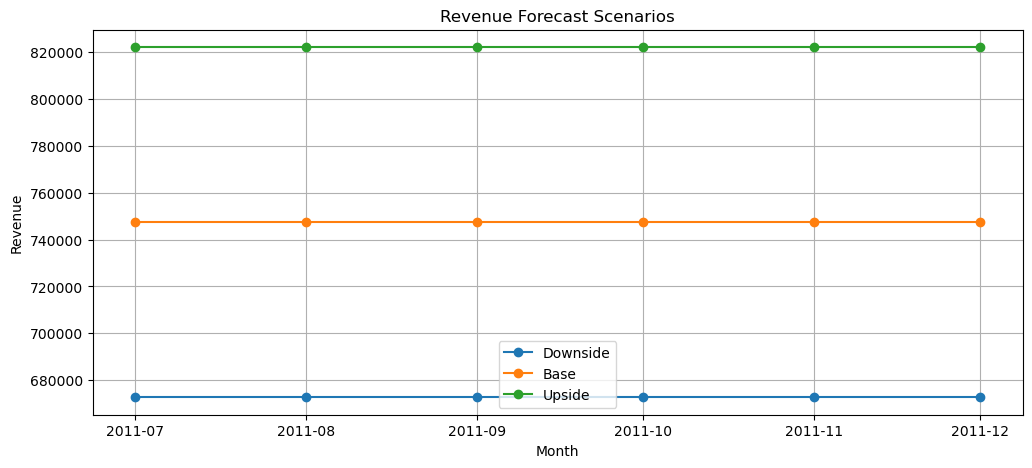

In [23]:
plt.figure(figsize=(12, 5))
plt.plot(forecast_df["month"], forecast_df["revenue_downside"], marker="o", label="Downside")
plt.plot(forecast_df["month"], forecast_df["revenue_base"], marker="o", label="Base")
plt.plot(forecast_df["month"], forecast_df["revenue_upside"], marker="o", label="Upside")
plt.title("Revenue Forecast Scenarios")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True)
plt.show()

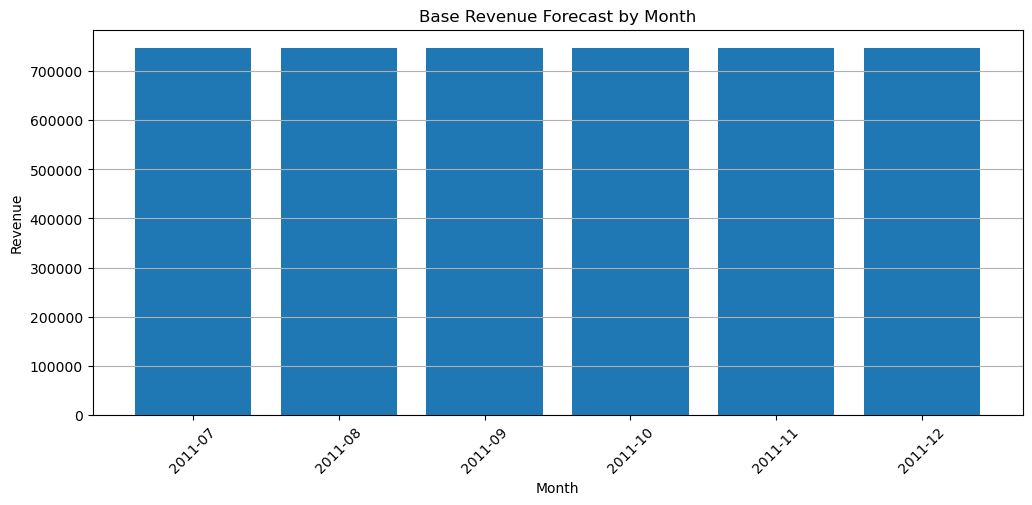

In [24]:
plt.figure(figsize=(12, 5))
plt.bar(forecast_df["month"].dt.strftime("%Y-%m"), forecast_df["revenue_base"])
plt.title("Base Revenue Forecast by Month")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(True, axis="y")
plt.show()

## 8. Total Scenario Summary

Summarize projected total revenue across scenarios.

In [25]:
summary = pd.DataFrame({
    "scenario": ["Downside", "Base", "Upside"],
    "total_revenue": [
        forecast_df["revenue_downside"].sum(),
        forecast_df["revenue_base"].sum(),
        forecast_df["revenue_upside"].sum()
    ]
})

summary

,scenario,total_revenue
0,Downside,4.036232e+06
1,Base,4.484702e+06
2,Upside,4.933172e+06


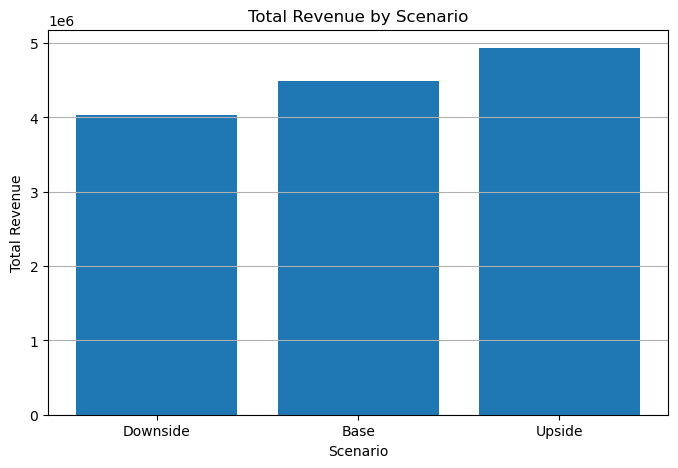

In [26]:
plt.figure(figsize=(8, 5))
plt.bar(summary["scenario"], summary["total_revenue"])
plt.title("Total Revenue by Scenario")
plt.xlabel("Scenario")
plt.ylabel("Total Revenue")
plt.grid(True, axis="y")
plt.show()

## 9. Business Interpretation

- The base scenario provides a central estimate for future revenue
- The downside scenario supports conservative planning
- The upside scenario supports growth target setting
- This framework helps connect forecasting outputs to financial planning

## 10. Conclusion

This notebook extends order forecasting into revenue-oriented business planning.

By combining forecasted order volume with recent Average Order Value (AOV),
it translates predictive analytics into practical business scenarios for:

- revenue planning
- inventory preparation
- executive KPI outlook